<a href="https://colab.research.google.com/github/RUPANARAYANAN-R/AIML/blob/main/Logistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
   area   price
0  2600  550000
1  3000  565000
2  3200  610000
3  3600  680000
4  4000  725000

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes
None

Statistical Summary:
              area          price
count     5.000000       5.000000
mean   3280.000000  626000.000000
std     540.370243   74949.983322
min    2600.000000  550000.000000
25%    3000.000000  565000.000000
50%    3200.000000  610000.000000
75%    3600.000000  680000.000000
max    4000.000000  725000.000000

Missing Values:
area     0
price    0
dtype: int64

Updated Dataset:
   area   price  cost_per_unit
0  2600  550000     211.538462
1  3000  565000     188.333333
2  3200  610000     190.625000
3  3600  680000     188.888889
4  4000  725000     181.250000


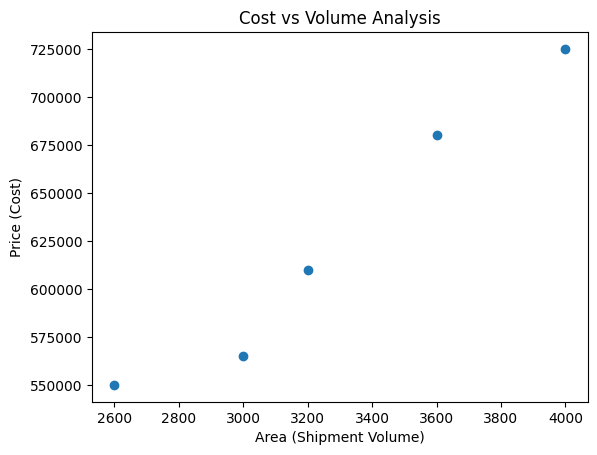

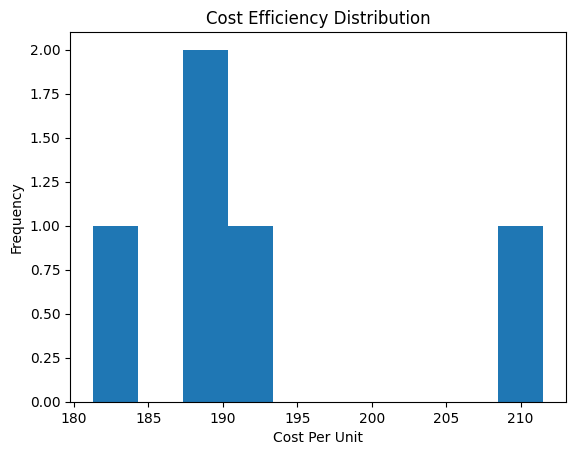

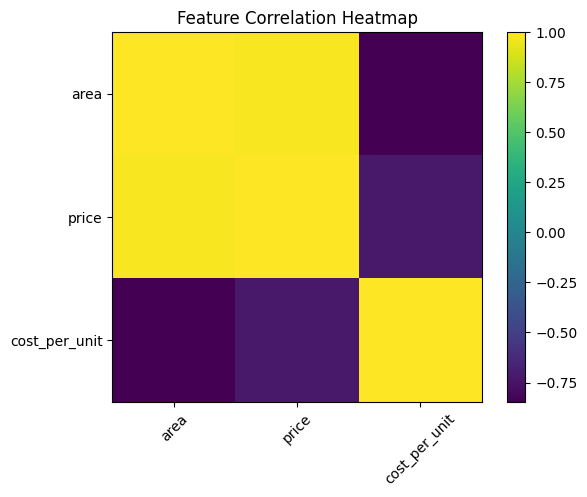

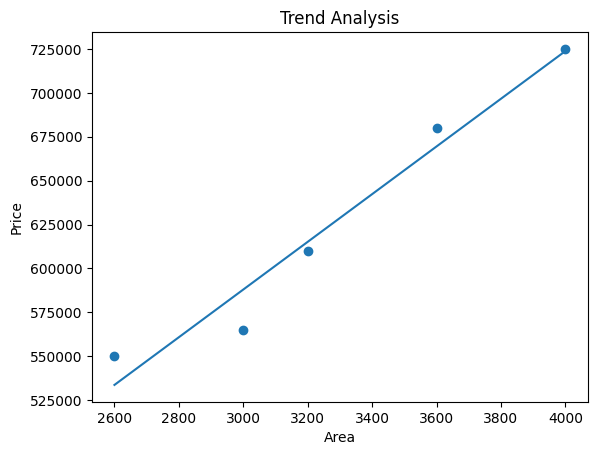


--- BUSINESS INSIGHTS ---
1. Average Cost Per Unit: 192.12713675213678
2. Maximum Cost Location:
area               4000.00
price            725000.00
cost_per_unit       181.25
Name: 4, dtype: float64
3. Minimum Cost Location:
area               2600.000000
price            550000.000000
cost_per_unit       211.538462
Name: 0, dtype: float64
4. Correlation between Area & Price: 0.9789944401374038


In [2]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_csv('homeprices.csv')

print("Dataset Preview:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ==============================
# 3. DATA CLEANING
# ==============================

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Fill missing values (if any)
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# ==============================
# 4. BASIC ANALYSIS (LOGISTICS ANALOGY)
# ==============================
# Assume:
# area → shipment volume
# price → cost

# Cost per unit (important KPI)
df['cost_per_unit'] = df['price'] / df['area']

print("\nUpdated Dataset:")
print(df.head())

# ==============================
# 5. CORRELATION ANALYSIS
# ==============================
correlation = df.corr(numeric_only=True)
print("\nCorrelation Matrix:")
print(correlation)

# ==============================
# 6. VISUALIZATION
# ==============================

# 1. Area vs Price (Core Logistics Insight)
plt.figure()
plt.scatter(df['area'], df['price'])
plt.xlabel("Area (Shipment Volume)")
plt.ylabel("Price (Cost)")
plt.title("Cost vs Volume Analysis")
plt.show()

# 2. Cost Per Unit Distribution
plt.figure()
plt.hist(df['cost_per_unit'], bins=10)
plt.xlabel("Cost Per Unit")
plt.ylabel("Frequency")
plt.title("Cost Efficiency Distribution")
plt.show()

# 3. Correlation Heatmap (Manual since seaborn not allowed)
plt.figure()
plt.imshow(correlation)
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Feature Correlation Heatmap")
plt.show()

# 4. Trend Line (Simple Regression Insight)
plt.figure()
plt.scatter(df['area'], df['price'])

# Best fit line
m = df['price'].corr(df['area']) * (df['price'].std() / df['area'].std())
b = df['price'].mean() - m * df['area'].mean()

y_pred = m * df['area'] + b
plt.plot(df['area'], y_pred)

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Trend Analysis")
plt.show()

# ==============================
# 7. BUSINESS INSIGHTS (PRINT)
# ==============================
print("\n--- BUSINESS INSIGHTS ---")

print("1. Average Cost Per Unit:", df['cost_per_unit'].mean())

print("2. Maximum Cost Location:")
print(df.loc[df['price'].idxmax()])

print("3. Minimum Cost Location:")
print(df.loc[df['price'].idxmin()])

print("4. Correlation between Area & Price:", df['area'].corr(df['price']))